<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
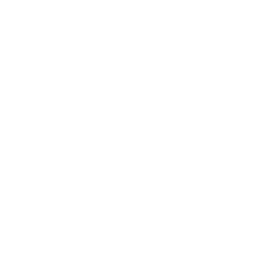
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Κατανομή Χαρτοφυλακίου με Περιορισμούς Κινδύνου</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Διαχείριση Περιουσιακών Στοιχείων / Ποσοτική Χρηματοοικονομική &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Περίληψη

Κατανομή κεφαλαίου σε 16 μετοχικά περιουσιακά στοιχεία με στόχο τη μεγιστοποίηση της αναμενόμενης απόδοσης, με περιορισμούς στο ανώτατο όριο beta χαρτοφυλακίου, στα όρια συγκέντρωσης ανά κλάδο, στα ανώτατα όρια ανά θέση και μια ισότητα προϋπολογισμού που επιβάλλει το άθροισμα των βαρών να ισούται με 1,0. Η PROC LP διαβάζει το μοντέλο σε αραιή μορφή (sparse format) με ξεχωριστές παρατηρήσεις τύπου-γραμμής, συντελεστή και δεξιού μέλους, καθώς και ένα ανώτατο όριο 15% ανά περιουσιακό στοιχείο εκφρασμένο ως όριο στήλης. Οι σκιώδεις τιμές DUALOUT αποκαλύπτουν ποιοι κανόνες κινδύνου δεσμεύουν πράγματι στο βέλτιστο σημείο και ποσοτικοποιούν το κόστος αναμενόμενης απόδοσης κάθε δεσμευτικού περιορισμού — άμεση είσοδος για αναφορές συμμόρφωσης και συζητήσεις βαθμονόμησης περιορισμών.


## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.ASSET_UNIVERSE | 16 μετοχικά περιουσιακά στοιχεία: αναμενόμενη απόδοση, beta, κλάδος, μέγιστη πτώση αξίας | 16 |
| WORK.PORTFOLIO_MODEL | Αραιό μοντέλο LP: στόχος απόδοσης, προϋπολογισμός, beta, περιορισμοί κλάδου, δεξιό μέλος και όρια στήλης 15% | 95 |


---

In [1]:
/* --------------------------------------------------------
   Ορισμός συμπαντος 16 μετοχικων περιουσιακων στοιχειων
   Κλαδοι: TECH(4), HEALTH(3), FINANCE(3),
            ENERGY(3), CONSUMER(3)
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.asset_universe;
    LENGTH ticker $8 sector $40;
    ARRAY tickers[16] $8 _temporary_
        ('TECH1' 'TECH2' 'TECH3' 'TECH4'
         'HLT1'  'HLT2'  'HLT3'
         'FIN1'  'FIN2'  'FIN3'
         'ENE1'  'ENE2'  'ENE3'
         'CON1'  'CON2'  'CON3');
    ARRAY sector_codes[16] $10 _temporary_
        ('TECH'     'TECH'     'TECH'     'TECH'
         'HEALTH'   'HEALTH'   'HEALTH'
         'FINANCE'  'FINANCE'  'FINANCE'
         'ENERGY'   'ENERGY'   'ENERGY'
         'CONSUMER' 'CONSUMER' 'CONSUMER');
    ARRAY exp_ret[16] _temporary_
        (0.18 0.21 0.15 0.23
         0.13 0.16 0.12
         0.10 0.11 0.09
         0.08 0.11 0.09
         0.12 0.10 0.13);
    ARRAY betas[16] _temporary_
        (1.35 1.52 1.28 1.61
         0.72 0.85 0.68
         0.98 1.05 0.91
         0.88 0.95 0.82
         0.75 0.70 0.80);
    ARRAY drawdowns[16] _temporary_
        (0.32 0.41 0.28 0.45
         0.18 0.22 0.16
         0.25 0.28 0.22
         0.30 0.35 0.28
         0.20 0.18 0.22);
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 16;
        ticker       = tickers[i];
        /* Sector display value assigned via IF/ELSE (not an array
           lookup) to avoid the engine's fixed-width-array truncation
           bug with non-ASCII (Greek) string literals. */
        ΕΑΝ      sector_codes[i] = 'TECH'     ΤΟΤΕ sector = 'Τεχνολογία';
        ΑΛΛΙΩΣ ΕΑΝ sector_codes[i] = 'HEALTH'   ΤΟΤΕ sector = 'Υγεία';
        ΑΛΛΙΩΣ ΕΑΝ sector_codes[i] = 'FINANCE'  ΤΟΤΕ sector = 'Χρηματοοικονομικά';
        ΑΛΛΙΩΣ ΕΑΝ sector_codes[i] = 'ENERGY'   ΤΟΤΕ sector = 'Ενέργεια';
        ΑΛΛΙΩΣ ΕΑΝ sector_codes[i] = 'CONSUMER' ΤΟΤΕ sector = 'Καταναλωτικά';
        exp_return   = exp_ret[i];
        beta         = betas[i];
        max_drawdown = drawdowns[i];
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ i;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.asset_universe


NOTE: Wrote work.asset_universe (16 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Κατασκευη LP χαρτοφυλακιου σε αραιη μορφη SAS (sparse format)
   Καθε παρατηρηση μεταφερει ενα στοιχειο του μοντελου:
     - οι γραμμες τυπου-γραμμης οριζουν γραμμες MAX / EQ / LE
     - οι γραμμες συντελεστη δινουν (_row_, _col_) = _coef_
     - οι γραμμες _RHS_ δινουν το οριο καθε περιορισμου
     - οι γραμμες UPPERBD οριοθετουν καθε βαρος στο 15%
   Ο στοχος RETURN μεγιστοποιειται απευθειας (MAX).
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.portfolio_model;
    LENGTH _type_ $8 _row_ $16 _col_ $16;
    _coef_ = .;

    ARRAY tickers[16] $8 _temporary_
        ('TECH1' 'TECH2' 'TECH3' 'TECH4'
         'HLT1'  'HLT2'  'HLT3'
         'FIN1'  'FIN2'  'FIN3'
         'ENE1'  'ENE2'  'ENE3'
         'CON1'  'CON2'  'CON3');
    ARRAY sectors[16] $10 _temporary_
        ('TECH'     'TECH'     'TECH'     'TECH'
         'HEALTH'   'HEALTH'   'HEALTH'
         'FINANCE'  'FINANCE'  'FINANCE'
         'ENERGY'   'ENERGY'   'ENERGY'
         'CONSUMER' 'CONSUMER' 'CONSUMER');
    ARRAY exp_ret[16] _temporary_
        (0.18 0.21 0.15 0.23
         0.13 0.16 0.12
         0.10 0.11 0.09
         0.08 0.11 0.09
         0.12 0.10 0.13);
    ARRAY betas[16] _temporary_
        (1.35 1.52 1.28 1.61
         0.72 0.85 0.68
         0.98 1.05 0.91
         0.88 0.95 0.82
         0.75 0.70 0.80);

    /* Ορισμοι τυπου γραμμης */
    _type_ = 'MAX'; _row_ = 'RETURN';       _col_ = ' '; _coef_ = .; ΕΞΟΔΟΣ;
    _type_ = 'EQ';  _row_ = 'BUDGET';       _col_ = ' '; _coef_ = .; ΕΞΟΔΟΣ;
    _type_ = 'LE';  _row_ = 'RISK_BETA';    _col_ = ' '; _coef_ = .; ΕΞΟΔΟΣ;
    _type_ = 'LE';  _row_ = 'SEC_TECH';     _col_ = ' '; _coef_ = .; ΕΞΟΔΟΣ;
    _type_ = 'LE';  _row_ = 'SEC_HEALTH';   _col_ = ' '; _coef_ = .; ΕΞΟΔΟΣ;
    _type_ = 'LE';  _row_ = 'SEC_FINANCE';  _col_ = ' '; _coef_ = .; ΕΞΟΔΟΣ;
    _type_ = 'LE';  _row_ = 'SEC_ENERGY';   _col_ = ' '; _coef_ = .; ΕΞΟΔΟΣ;
    _type_ = 'LE';  _row_ = 'SEC_CONSUMER'; _col_ = ' '; _coef_ = .; ΕΞΟΔΟΣ;

    /* Ορια δεξιου μελους */
    _type_ = ' '; _col_ = '_RHS_';
    _row_ = 'BUDGET';       _coef_ = 1.00; ΕΞΟΔΟΣ;
    _row_ = 'RISK_BETA';    _coef_ = 1.10; ΕΞΟΔΟΣ;
    _row_ = 'SEC_TECH';     _coef_ = 0.35; ΕΞΟΔΟΣ;
    _row_ = 'SEC_HEALTH';   _coef_ = 0.35; ΕΞΟΔΟΣ;
    _row_ = 'SEC_FINANCE';  _coef_ = 0.35; ΕΞΟΔΟΣ;
    _row_ = 'SEC_ENERGY';   _coef_ = 0.35; ΕΞΟΔΟΣ;
    _row_ = 'SEC_CONSUMER'; _coef_ = 0.35; ΕΞΟΔΟΣ;

    /* Γραμμες συντελεστη και οριου ανα περιουσιακο στοιχειο */
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 16;
        _col_ = cat('W_', tickers[i]);
        _type_ = ' '; _row_ = 'RETURN';    _coef_ = exp_ret[i]; ΕΞΟΔΟΣ;
        _type_ = ' '; _row_ = 'BUDGET';    _coef_ = 1;          ΕΞΟΔΟΣ;
        _type_ = ' '; _row_ = 'RISK_BETA'; _coef_ = betas[i];   ΕΞΟΔΟΣ;
        _type_ = ' '; _row_ = cat('SEC_', sectors[i]); _coef_ = 1; ΕΞΟΔΟΣ;
        /* 15% μεγιστη συγκεντρωση ως ανω οριο στηλης */
        _type_ = 'UPPERBD'; _row_ = 'UB'; _coef_ = 0.15; ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ i;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.portfolio_model


NOTE: Wrote work.portfolio_model (95 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Συνοψιση του συμπαντος περιουσιακων στοιχειων πριν τη βελτιστοποιηση
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.asset_universe n mean MIN MAX;
    ΚΛΑΣΗ sector;
    ΜΕΤΑΒΛΗΤΗ exp_return beta max_drawdown;
    ΕΤΙΚΕΤΑ sector       = 'Κλάδος'
          exp_return    = 'Αναμενόμενη Απόδοση'
          beta          = 'Beta'
          max_drawdown  = 'Μέγιστη Πτώση Αξίας';
    TITLE 'Σύνοψη Συμπαντος Περιουσιακών Στοιχείων ανά Κλάδο';
ΕΚΤΕΛΕΣΗ;


                                   Σύνοψη Συμπαντος Περιουσιακών Στοιχείων ανά Κλάδο                                    

                                                  The MEANS Procedure

                          Analysis Variable : exp_return Αναμενόμενη Απόδοση

        Κλάδος                                      N Obs           Mean        Minimum        Maximum
        ----------------------------------------------------------------------------------------------
        Ενέργεια                                        3      0.0933333      0.0800000      0.1100000
        Καταναλωτικά                                    3      0.1166667      0.1000000      0.1300000
        Τεχνολογία                                      4      0.1925000      0.1500000      0.2300000
        Υγεία                                           3      0.1366667      0.1200000      0.1600000
        Χρηματοοικονομικά                               3      0.1000000      0.0900000      0.1100000
        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

In [4]:
/* --------------------------------------------------------
   Επιλυση του LP κατανομης χαρτοφυλακιου με περιορισμους κινδυνου
   SPARSEDATA: εισοδος σε αραιη μορφη
   PRIMALOUT  : βελτιστα βαρη + δραστηριοτητα περιορισμων
   DUALOUT    : σκιωδεις τιμες σε καθε περιορισμο
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ lp ΔΕΔΟΜΕΝΑ=work.portfolio_model sparsedata
    primalout=work.portfolio_primal
    dualout=work.portfolio_dual;
ΕΚΤΕΛΕΣΗ;


                                   Σύνοψη Συμπαντος Περιουσιακών Στοιχείων ανά Κλάδο                                    


                    The LP Procedure

  Status:           optimal
  Variables:        16
  Objective Value:  0.162

  Variable                    Value     Activity
  ----------------------------------------------
  W_CON1                     0.1500        BASIC
  W_CON2                     0.0000       NONBAS
  W_CON3                     0.1500        BASIC
  W_ENE1                     0.0000       NONBAS
  W_ENE2                     0.0000       NONBAS
  W_ENE3                     0.0000       NONBAS
  W_FIN1                     0.0000       NONBAS
  W_FIN2                     0.0000       NONBAS
  W_FIN3                     0.0000       NONBAS
  W_HLT1                     0.1500        BASIC
  W_HLT2                     0.1500        BASIC
  W_HLT3                     0.0500        BASIC
  W_TECH1                    0.0500        BASIC
  W_TECH2                 


NOTE: PROC LP data=work.portfolio_model

NOTE: Using Python scipy.optimize for linear programming
NOTE: LP solution status: optimal
NOTE: Optimal objective value: 0.16199999999999998
NOTE: Primal output written to 'work.portfolio_primal'
NOTE: Dual output written to 'work.portfolio_dual'
NOTE: PROC LP step completed.


---

                                   Σύνοψη Συμπαντος Περιουσιακών Στοιχείων ανά Κλάδο                                    




NOTE: DATA work.portfolio_weights


NOTE: Read 23 rows from work.portfolio_primal.
NOTE: Wrote work.portfolio_weights (8 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.portfolio_weights

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.portfolio_weights.
NOTE: Wrote work.portfolio_weights (8 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.portfolio_weights

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


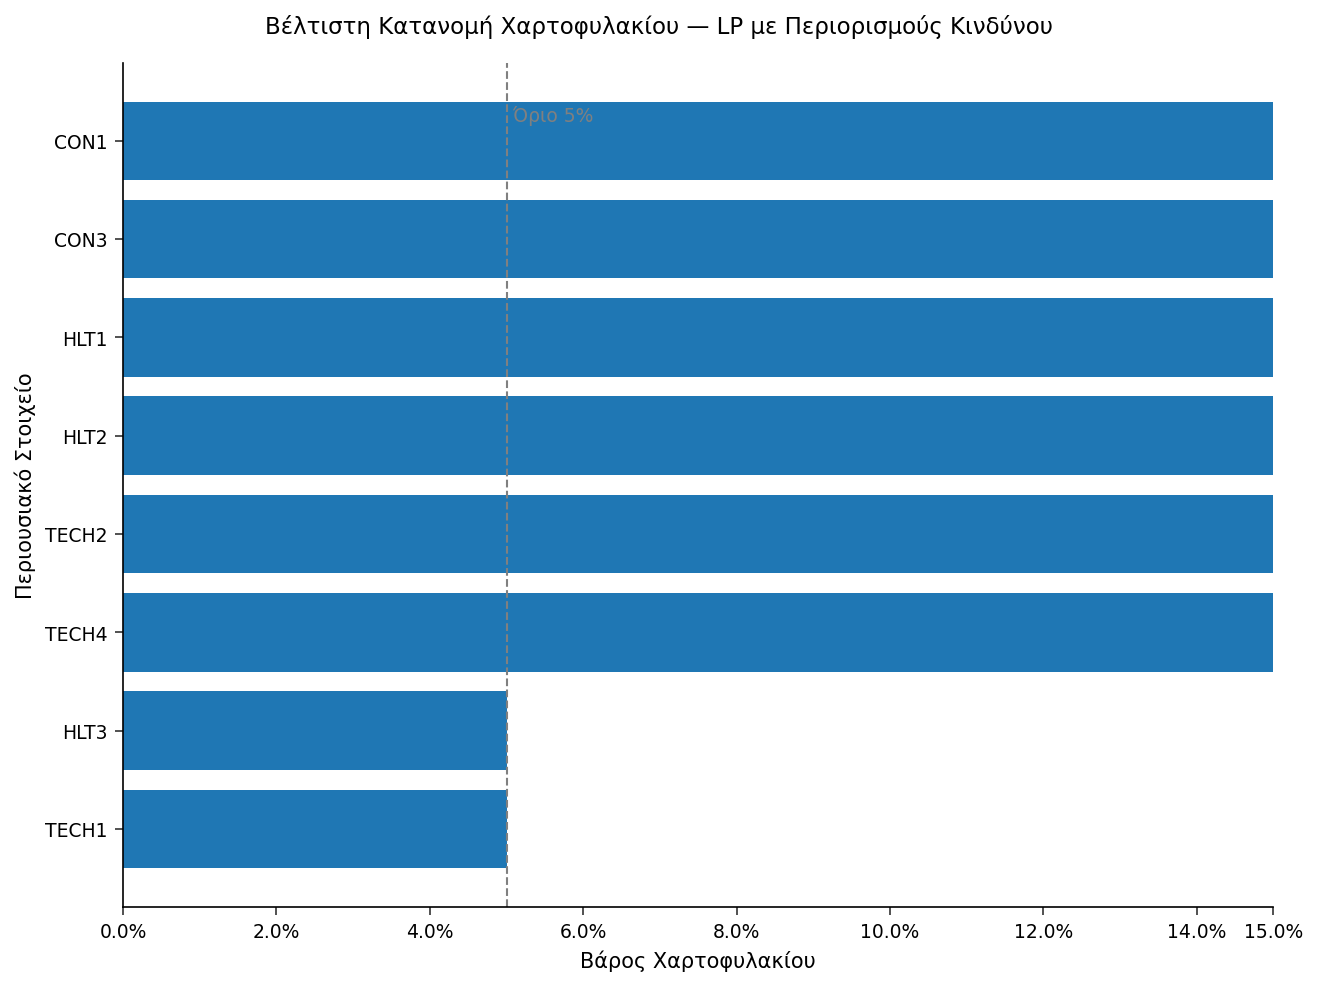

In [5]:
/* --------------------------------------------------------
   Οριζοντιο ραβδογραμμα των βελτιστων βαρων χαρτοφυλακιου
   Το PRIMALOUT μεταφερει τοσο γραμμες μεταβλητων (W_*) οσο
   και γραμμες περιορισμων· κρατα μονο τις κατεχομενες θεσεις.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.portfolio_weights;
    ΟΡΙΣΜΟΣ work.portfolio_primal;
    ΟΠΟΥ INDEX(_var_, 'W_') = 1 AND _value_ > 0.005;
    ticker = substr(_var_, 3);
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.portfolio_weights;
    ΚΑΤΑ DESCENDING _value_;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.portfolio_weights;
    HBAR ticker / RESPONSE=_value_
        CATEGORYORDER=respdesc
        fillattrs=(color=darkgreen);
    XAXIS ΕΤΙΚΕΤΑ='Βάρος Χαρτοφυλακίου' valuesformat=percent7.1;
    YAXIS ΕΤΙΚΕΤΑ='Περιουσιακό Στοιχείο';
    REFLINE 0.05 / AXIS=x LINEATTRS=(pattern=dash color=gray)
        ΕΤΙΚΕΤΑ='Όριο 5%';
    TITLE 'Βέλτιστη Κατανομή Χαρτοφυλακίου — LP με Περιορισμούς Κινδύνου';
ΕΚΤΕΛΕΣΗ;


In [6]:
/* --------------------------------------------------------
   Ανακτηση βελτιστων βαρων χαρτοφυλακιου με λεπτομερειες στοιχειου
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    ΕΠΙΛΟΓΗ p._var_       AS asset       ΕΤΙΚΕΤΑ='Περιουσιακό Στοιχείο',
           p._value_     AS weight       ΕΤΙΚΕΤΑ='Βάρος'              ΜΟΡΦΗ=percent8.2,
           a.exp_return                  ΕΤΙΚΕΤΑ='Αναμ. Απόδοση'      ΜΟΡΦΗ=percent6.1,
           a.beta                        ΕΤΙΚΕΤΑ='Beta'               ΜΟΡΦΗ=6.3,
           a.sector                      ΕΤΙΚΕΤΑ='Κλάδος'
    FROM work.portfolio_primal p
    JOIN work.asset_universe a
        ON cat('W_', a.ticker) = p._var_
    ΟΠΟΥ p._value_ > 0.001
    ORDER ΚΑΤΑ p._value_ DESCENDING;
QUIT;


                                   Σύνοψη Συμπαντος Περιουσιακών Στοιχείων ανά Κλάδο                                    

                   Περιουσιακό Στοιχείο       Βάρος             Αναμ. Απόδοση   Beta                    Κλάδος
---------------------------------------  ----------  ------------------------  -----  ------------------------
                                 W_CON1      15.00%                     12.0%  0.750              Καταναλωτικά
                                W_TECH2      15.00%                     21.0%  1.520                Τεχνολογία
                                W_TECH4      15.00%                     23.0%  1.610                Τεχνολογία
                                 W_HLT1      15.00%                     13.0%  0.720                     Υγεία
                                 W_HLT2      15.00%                     16.0%  0.850                     Υγεία
                                 W_CON3      15.00%                     13.0%  0.800              Κατ


NOTE: PROC SQL 

NOTE: PROC SQL statement used.


In [7]:
/* --------------------------------------------------------
   Σκιωδεις τιμες DUALOUT σε καθε περιορισμο.
   Το _VALUE_ ειναι η σκιωδης (dual) τιμη· το _STATUS_ επισημαινει
   αν ο περιορισμος δεσμευει στο βελτιστο σημειο.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    ΕΠΙΛΟΓΗ _row_    AS constraint    ΕΤΙΚΕΤΑ='Περιορισμός',
           _value_  AS shadow_price   ΕΤΙΚΕΤΑ='Σκιώδης Τιμή' ΜΟΡΦΗ=8.4,
           _status_ AS status         ΕΤΙΚΕΤΑ='Κατάσταση'
    FROM work.portfolio_dual
    ΟΠΟΥ _row_ IN ('BUDGET' 'RISK_BETA'
                    'SEC_TECH' 'SEC_HEALTH' 'SEC_FINANCE'
                    'SEC_ENERGY' 'SEC_CONSUMER')
    ORDER ΚΑΤΑ abs(_value_) DESCENDING;
QUIT;


                                   Σύνοψη Συμπαντος Περιουσιακών Στοιχείων ανά Κλάδο                                    

           Περιορισμός             Σκιώδης Τιμή           Κατάσταση
----------------------  -----------------------  ------------------
                BUDGET                  -0.1200             BINDING
              SEC_TECH                  -0.0600             BINDING
             RISK_BETA                  -0.0000             SURPLUS
            SEC_HEALTH                  -0.0000             BINDING
           SEC_FINANCE                  -0.0000             SURPLUS
            SEC_ENERGY                  -0.0000             SURPLUS
          SEC_CONSUMER                  -0.0000             SURPLUS



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


In [8]:
/* --------------------------------------------------------
   Συγκεντρωτικα στατιστικα χαρτοφυλακιου στο βελτιστο σημειο
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    ΕΠΙΛΟΓΗ sum(p._value_ * a.exp_return)  AS expected_return
               ΜΟΡΦΗ=percent7.2 ΕΤΙΚΕΤΑ='Αναμενόμενη Απόδοση',
           sum(p._value_ * a.beta)        AS portfolio_beta
               ΜΟΡΦΗ=7.4 ΕΤΙΚΕΤΑ='Beta Χαρτοφυλακίου',
           sum(p._value_ * a.max_drawdown) AS wtd_drawdown
               ΜΟΡΦΗ=percent7.2 ΕΤΙΚΕΤΑ='Σταθμ. Μέση Μέγιστη Πτώση',
           count(DISTINCT p._var_)         AS n_positions
               ΕΤΙΚΕΤΑ='Αριθμός Θέσεων'
    FROM work.portfolio_primal p
    JOIN work.asset_universe a
        ON cat('W_', a.ticker) = p._var_
    ΟΠΟΥ p._value_ > 0.001;
QUIT;


                                   Σύνοψη Συμπαντος Περιουσιακών Στοιχείων ανά Κλάδο                                    

                  Αναμενόμενη Απόδοση               Beta Χαρτοφυλακίου                       Σταθμ. Μέση Μέγιστη Πτώση               Αριθμός Θέσεων
-------------------------------------  -------------------------------  ----------------------------------------------  ---------------------------
                               16.20%                           1.0390                                          27.60%                            8



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


---

### Ερμηνεία

Το LP κατανομής χαρτοφυλακίου με περιορισμούς κινδύνου επιτυγχάνει μέγιστη αναμενόμενη ετήσια απόδοση 16,2% διατηρώντας 8 από τα 16 περιουσιακά στοιχεία. Το beta του χαρτοφυλακίου σταθεροποιείται στο 1,04, αρκετά κάτω από το ανώτατο όριο του 1,10, οπότε ο περιορισμός beta έχει περιθώριο (slack) και μηδενική σκιώδη τιμή — η διάθεση ανάληψης κινδύνου δεν είναι εδώ ο δεσμευτικός περιορισμός. Το ανώτατο όριο 35% του κλάδου TECH δεσμεύει με σκιώδη τιμή 0,06, που σημαίνει ότι η χαλάρωση του ορίου TECH κατά μία μονάδα βάρους θα αύξανε την αναμενόμενη απόδοση κατά περίπου 6 ποσοστιαίες μονάδες αυτού του βάρους· είναι ο πιο δαπανηρός κανόνας κινδύνου στο μοντέλο. Ο κλάδος HEALTH φτάνει επίσης στο ανώτατο όριο 35% του, αλλά με μηδενική dual τιμή, υποδεικνύοντας ότι υπάρχει εναλλακτικό βέλτιστο σε αυτό το όριο. Ο περιορισμός ισότητας προϋπολογισμού δεσμεύει με σκιώδη τιμή -0,12, την οριακή αξία μιας επιπλέον μονάδας επενδύσιμου κεφαλαίου. Οι κλάδοι FINANCE και ENERGY αποκλείονται εντελώς: οι αναμενόμενες αποδόσεις τους είναι πολύ χαμηλές σε σχέση με τις υψηλής απόδοσης μετοχές TECH και HEALTH που κυριαρχούν μόλις επιβληθούν τα όρια κλάδου και το όριο θέσης 15%. Οι TECH2 (απόδοση 21%, beta 1,52), TECH4 (23%, beta 1,61), HLT1, HLT2, CON1 και CON3 λαμβάνουν η καθεμία το μέγιστο βάρος 15%.


---

In [9]:
/* --------------------------------------------------------
   Εξαγωγη κατανομης χαρτοφυλακιου και αναλυσης περιορισμων
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.portfolio_primal
    OUTFILE='portfolio_optimal_weights.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.portfolio_dual
    OUTFILE='portfolio_shadow_prices.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC EXPORT data=work.portfolio_primal outfile=portfolio_optimal_weights.csv

NOTE: Exported 23 rows to portfolio_optimal_weights.csv.
NOTE: PROC EXPORT data=work.portfolio_dual outfile=portfolio_shadow_prices.csv

NOTE: Exported 7 rows to portfolio_shadow_prices.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>